#외국인 범죄자 직업 -> plot

In [3]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
# import matplotib.font_manager as fm

# 한글 폰트 설정
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지



In [4]:
# 절대경로나 상대경로 사용 가능
file_path = r"대검찰청_외국인범죄자 직업_20171231.csv"
df = pd.read_csv(file_path, encoding='cp949')  # 또는 encoding='utf-8-sig'
df.head()

,범죄분류,농임수산업,광업,제조업,건설업,도소매업,무역업,요식업,숙박업,유흥업,...,종교가,언론인,예술인,기타전문직,공무원,군인,학생,주부,무직자,미상
0,절도,11,0,9,18,2,17,8,2,4,...,0,1,11,65,1,0,249,50,943,433
1,장물,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,4,1,13,10
2,사기,6,0,5,10,16,26,19,2,4,...,3,0,4,46,0,0,157,33,989,486
3,횡령,5,0,5,5,1,5,3,1,1,...,4,1,0,16,1,0,60,8,139,103
4,배임,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,5,9


In [ ]:
print(df.shape)
print(df.columns)
print(df.info())

(95, 44)
Index(['범죄분류', '농임수산업', '광업', '제조업', '건설업', '도소매업', '무역업', '요식업', '숙박업', '유흥업',
       '금융업', '부동산업', '의료보건업', '차량정비업', '노점', '행상', '기타사업', '교원(사립)', '사무원',
       '기술자', '점원', '공원', '운전자', '경비원', '외판원', '일반회사원', '금융기관직원', '유흥업종사자',
       '요식업종사자', '일용노동자', '기타피고용자', '의사', '변호사', '교수', '종교가', '언론인', '예술인',
       '기타전문직', '공무원', '군인', '학생', '주부', '무직자', '미상'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 44 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   범죄분류    95 non-null     object
 1   농임수산업   95 non-null     int64 
 2   광업      95 non-null     int64 
 3   제조업     95 non-null     int64 
 4   건설업     95 non-null     int64 
 5   도소매업    95 non-null     int64 
 6   무역업     95 non-null     int64 
 7   요식업     95 non-null     int64 
 8   숙박업     95 non-null     int64 
 9   유흥업     95 non-null     int64 
 10  금융업     95 non-null     int64 
 11  부동산업    95 non-null     int64

In [ ]:
print(df.isnull().sum())

범죄분류      0
농임수산업     0
광업        0
제조업       0
건설업       0
도소매업      0
무역업       0
요식업       0
숙박업       0
유흥업       0
금융업       0
부동산업      0
의료보건업     0
차량정비업     0
노점        0
행상        0
기타사업      0
교원(사립)    0
사무원       0
기술자       0
점원        0
공원        0
운전자       0
경비원       0
외판원       0
일반회사원     0
금융기관직원    0
유흥업종사자    0
요식업종사자    0
일용노동자     0
기타피고용자    0
의사        0
변호사       0
교수        0
종교가       0
언론인       0
예술인       0
기타전문직     0
공무원       0
군인        0
학생        0
주부        0
무직자       0
미상        0
dtype: int64


# 3. 체류자격 컬럼 필터링
criminal_sums = df.columns[1:27].apply(pd.to_numeric, errors= 'coerce').fillna(0)
#직업'미상'인 열 제거 
df = df.loc[:, ~df.columns.str.contains('미상')]
job_cols = df.iloc[:, 3:9].fillna(0).astype(int)

# 4. 직업 결측치 처리 : NaN → 0, float → int
df[job_cols] = df[job_cols].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)
#범죄 종류 저장 
Criminal_div = df['범죄분류'].unique()
 

In [ ]:
# '직업' 관련 컬럼 중 '미상'이 포함되지 않은 컬럼만 선택
job_cols = [col for col in df.columns if '직업' in col and '미상' not in col]
# 숫자형으로 변환 및 결측치 처리
df[job_cols] = df[job_cols].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

criminal_div = df['범죄분류'].unique()
criminal_div = [c for c in criminal_div if '기타특별법' not in c]
# 범죄분류별 직업별 합계 테이블 생성
pivot_df = df[df['범죄분류'].isin(criminal_div)].groupby('범죄분류')[job_cols].sum()



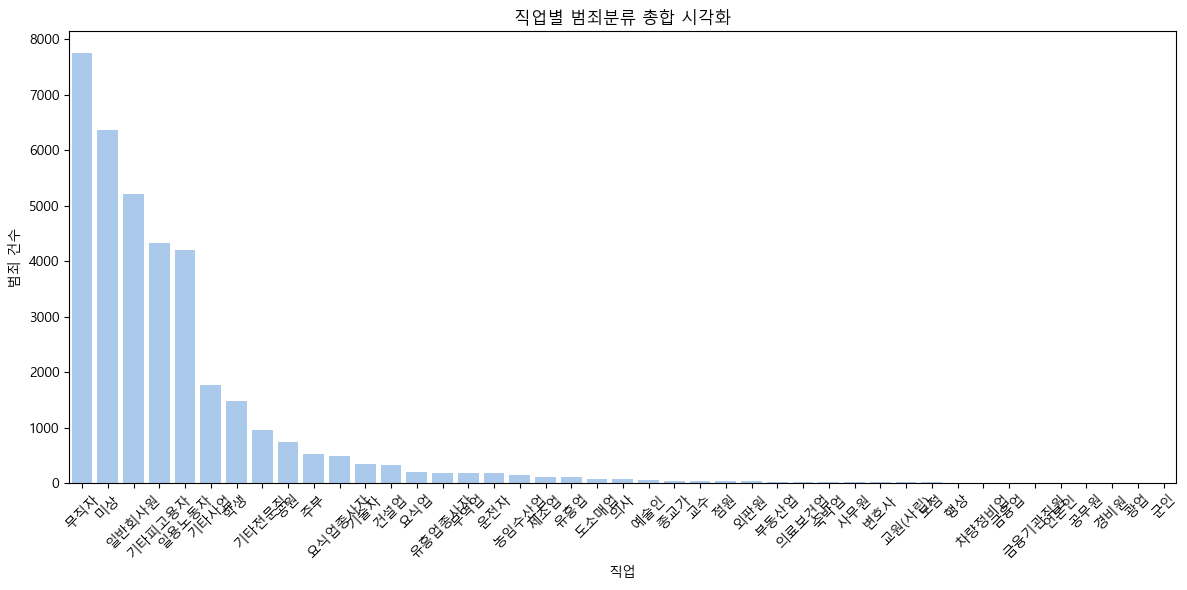

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# '범죄분류'를 제외한 나머지 열들을 직업 열로 간주
job_cols = df.columns[1:]

# 직업별 총합 계산
criminal_sum = df[job_cols].sum().sort_values(ascending=False)

# 시각화
sns.set_palette("pastel")
plt.figure(figsize=(12, 6))
sns.barplot(x=criminal_sum.index, y=criminal_sum.values)
plt.title('직업별 범죄분류 총합 시각화')
plt.xlabel('직업')
plt.ylabel('범죄 건수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


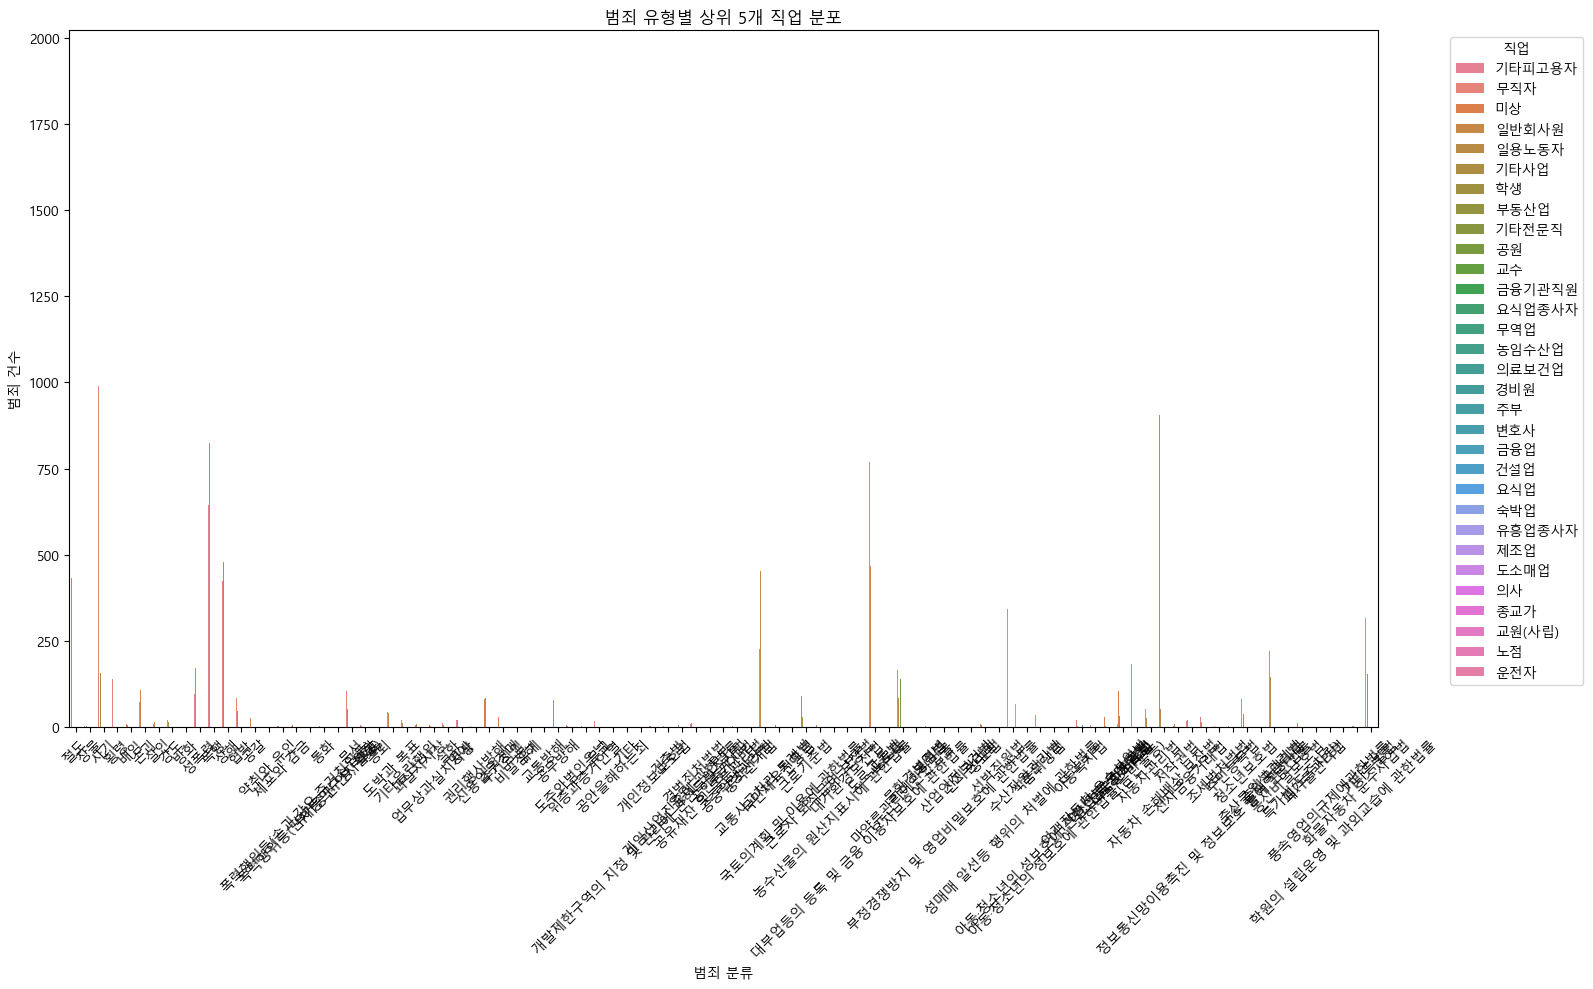

In [ ]:
# 데이터프레임에서 '범죄분류'를 인덱스로 설정
heatmap_data = df.set_index('범죄분류')

# 각 범죄 유형에서 상위 5개 직업 추출 후 long-form 형태로 변환
top5_jobs_per_crime = (
    heatmap_data.apply(lambda row: row.sort_values(ascending=False).iloc[:5], axis=1)
    .stack()
    .reset_index()
)
top5_jobs_per_crime.columns = ['범죄분류', '직업', '건수']

# bar plot 시각화
plt.figure(figsize=(16, 10))
sns.barplot(data=top5_jobs_per_crime, x='범죄분류', y='건수', hue='직업')
plt.title('범죄 유형별 상위 5개 직업 분포')
plt.xlabel('범죄 분류')
plt.ylabel('범죄 건수')
plt.legend(title='직업', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# '범죄분류'를 인덱스로 설정
heatmap_data = df.set_index('범죄분류')

# 각 범죄 유형별 상위 5개 직업 추출 → long-form 변환
top5_jobs_per_crime = (
    heatmap_data.apply(lambda row: row.sort_values(ascending=False).iloc[:5], axis=1)
    .stack()
    .reset_index()
)
top5_jobs_per_crime.columns = ['범죄분류', '직업', '건수']

# 건수 기준 내림차순 정렬
top5_sorted_table = top5_jobs_per_crime.sort_values(by='건수', ascending=False).reset_index(drop=True)

# 테이블 출력 (Jupyter 환경에서)
top5_sorted_table.head()


,범죄분류,직업,건수
0,도로교통법,일반회사원,1925.0
1,폭행,무직자,1156.0
2,도로교통법,일용노동자,995.0
3,사기,무직자,989.0
4,도로교통법,무직자,970.0
